# 01 — Dataset and individual measurement points

This first step builds only the data foundation. Each experimental dataset contains exactly one
raw measurement point—no averages, slopes, time constants, or combined features yet.

Source: [Zenodo DOI 10.5281/zenodo.6821340](https://doi.org/10.5281/zenodo.6821340).
Sensor A and channel 0 are fixed. UGM 1–500 are grouped into train, validation, and test;
UGM 501–906 remain an exclusive extrapolation test.

## Software and configurable values

This notebook introduces data access. `dataset_pipeline.py` contains the shared loading,
validation, grouping, transformation, and export rules so later notebooks use identical data.

- `pathlib`, `urllib`, and `hashlib` locate, download, and verify the public file.
- `h5py` reads the MATLAB v7.3/HDF5 data; NumPy stores cycles as
  `(cycles, sensors, samples)` arrays.
- scikit-learn's `GroupShuffleSplit` keeps every UGM ID in exactly one split.

`transform` can be `stored` or the additional `log1p` transformation. Sensor A, channel 0,
and a sensor dimension of length one are fixed for this seminar. UGM 1–500 are split into
train, validation, and test; UGM 501–906 form the exclusive `test_extra` set. Never use either
test split for point selection, correlation screening, or hyperparameter selection.

In [1]:
from pathlib import Path
import sys
import numpy as np

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Day_02"
sys.path.insert(0, str(HERE.resolve()))
from dataset_pipeline import *

## 1. Source and concentration range

Zenodo reports acetone ranges of 3–50 ppb for UGM 1–200, 3–150 ppb for UGM 201–500,
and 3–500 ppb for UGM 501–906. No concentration is removed. The first two ranges support
interpolation evaluation; the final range is reserved for extrapolation.

In [2]:
path = ensure_dataset(download=True, verify=True)
print("Dataset:", path)
print("Zenodo DOI:", ZENODO_DOI)

Dataset: \\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\fullData.mat
Zenodo DOI: 10.5281/zenodo.6821340


## 2. Load one channel and freeze the grouped split

In [3]:
splits = prepare_splits("stored")
for name in SPLIT_NAMES:
    X = splits[name]["X"]
    targets = splits[name]["targets"]
    print(
        f"{name:>5}: X={X.shape}, "
        f"UGMs={len(np.unique(targets['range']))}, "
        f"Acetonee={targets['acetone'].min():.1f}-"
        f"{targets['acetone'].max():.1f} ppb"
    )

train: X=(1090, 1, 1440), UGMs=318, Acetonee=3.1-148.6 ppb
  val: X=(274, 1, 1440), UGMs=80, Acetonee=4.5-150.0 ppb
 test: X=(338, 1, 1440), UGMs=100, Acetonee=4.6-144.3 ppb
test_extra: X=(1392, 1, 1440), UGMs=402, Acetonee=3.0-499.9 ppb


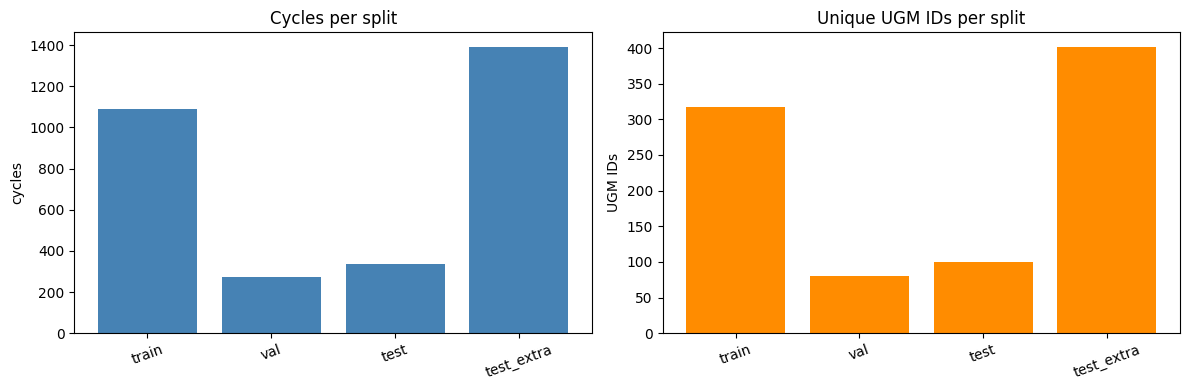

In [4]:
import matplotlib.pyplot as plt

split_sizes = [len(splits[name]["X"]) for name in SPLIT_NAMES]
ugm_counts = [
    len(np.unique(splits[name]["targets"]["range"]))
    for name in SPLIT_NAMES
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(SPLIT_NAMES, split_sizes, color="steelblue")
axes[0].set(title="Cycles per split", ylabel="cycles")
axes[1].bar(SPLIT_NAMES, ugm_counts, color="darkorange")
axes[1].set(title="Unique UGM IDs per split", ylabel="UGM IDs")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
fig.tight_layout()

The array shape is `(samples, 1, 1440)`. No split shares a UGM ID with another split,
and `test_extra` contains only UGM 501–906. The next figure makes these boundaries visible.

## 3. Use only the start and end of each temperature phase

In [5]:
points = temperature_boundary_points()
print("Allowed points:", len(points))
for point in points[:8]:
    print(point)

Allowed points: 48
BoundaryPoint(index=0, temperature_c=400, phase='high', cycle_step=0, edge='start')
BoundaryPoint(index=49, temperature_c=400, phase='high', cycle_step=0, edge='end')
BoundaryPoint(index=50, temperature_c=100, phase='low', cycle_step=0, edge='start')
BoundaryPoint(index=119, temperature_c=100, phase='low', cycle_step=0, edge='end')
BoundaryPoint(index=120, temperature_c=400, phase='high', cycle_step=1, edge='start')
BoundaryPoint(index=169, temperature_c=400, phase='high', cycle_step=1, edge='end')
BoundaryPoint(index=170, temperature_c=125, phase='low', cycle_step=1, edge='start')
BoundaryPoint(index=239, temperature_c=125, phase='low', cycle_step=1, edge='end')


Each cycle contains twelve 400 °C phases of 5 seconds and twelve low-temperature phases
of 7 seconds. Low temperatures increase from 100 °C to 375 °C. Only phase starts and ends are
allowed at this stage.

## 4. Correlation and cross-sensitivity from training data only

In [6]:
for gas in GAS_TARGETS:
    chosen = selected_point_scores(score_boundary_points(splits, gas))
    best = chosen["best_correlation"]
    selective = chosen["best_selectivity"]
    print(
        f"{gas:18s} | best: {best.point_id}, r={best.target_correlation:+.3f}"
        f" | selective: {selective.point_id}, "
        f"r={selective.target_correlation:+.3f}, "
        f"interferer={selective.strongest_interferer}, "
        f"margin={selective.selectivity_margin:+.3f}"
    )

acetic_acid        | best: t325_low_step09_start_i1130, r=-0.416 | selective: t100_low_step00_start_i0050, r=-0.216, interferer=ethyl_acetate, margin=-0.103
acetone            | best: t400_high_step02_end_i0289, r=-0.522 | selective: t150_low_step02_start_i0290, r=-0.338, interferer=ethyl_acetate, margin=-0.059
carbon_monoxide    | best: t100_low_step00_end_i0119, r=-0.216 | selective: t100_low_step00_start_i0050, r=+0.026, interferer=ethyl_acetate, margin=-0.292
ethanol            | best: t400_high_step02_start_i0240, r=-0.428 | selective: t100_low_step00_start_i0050, r=-0.209, interferer=ethyl_acetate, margin=-0.110
ethyl_acetate      | best: t400_high_step03_end_i0409, r=-0.655 | selective: t400_high_step01_start_i0120, r=-0.622, interferer=acetone, margin=+0.137
formaldehyde       | best: t275_low_step07_start_i0890, r=-0.351 | selective: t100_low_step00_start_i0050, r=-0.180, interferer=ethyl_acetate, margin=-0.139
hydrogen           | best: t400_high_step11_start_i1320, r=-0.608 

The selectivity margin is target correlation minus the strongest correlation with another
gas or humidity. It is a screening score, not proof of chemical selectivity.

## 5. Separate points for each temperature

In [7]:
target = "acetone"
selected = selected_point_scores(score_boundary_points(splits, target))
datasets = {
    name: build_point_dataset(splits, target, score)
    for name, score in selected.items()
}
for name, dataset in datasets.items():
    score = selected[name]
    print(
        f"{name:18s}: i={score.index:4d}, T={score.temperature_c:3d} °C, "
        f"{score.edge:5s}, r={score.target_correlation:+.3f}, "
        f"X_train={dataset['X_train'].shape}"
    )

best_correlation  : i= 289, T=400 °C, end  , r=-0.522, X_train=(1090, 1, 1)
best_selectivity  : i= 290, T=150 °C, start, r=-0.338, X_train=(1090, 1, 1)
temperature_100C  : i= 119, T=100 °C, end  , r=-0.403, X_train=(1090, 1, 1)
temperature_125C  : i= 239, T=125 °C, end  , r=-0.445, X_train=(1090, 1, 1)
temperature_150C  : i= 359, T=150 °C, end  , r=-0.446, X_train=(1090, 1, 1)
temperature_175C  : i= 479, T=175 °C, end  , r=-0.442, X_train=(1090, 1, 1)
temperature_200C  : i= 530, T=200 °C, start, r=-0.462, X_train=(1090, 1, 1)
temperature_225C  : i= 650, T=225 °C, start, r=-0.510, X_train=(1090, 1, 1)
temperature_250C  : i= 770, T=250 °C, start, r=-0.511, X_train=(1090, 1, 1)
temperature_275C  : i= 890, T=275 °C, start, r=-0.509, X_train=(1090, 1, 1)
temperature_300C  : i=1010, T=300 °C, start, r=-0.507, X_train=(1090, 1, 1)
temperature_325C  : i=1130, T=325 °C, start, r=-0.507, X_train=(1090, 1, 1)
temperature_350C  : i=1250, T=350 °C, start, r=-0.504, X_train=(1090, 1, 1)
temperature_

## 6. Export all gas and point variants

In [8]:
output_dir = project_root() / "Data" / "seminar_point_datasets"
manifest = export_point_datasets(output_dir)
print("Manifest:", manifest)
for transform in TRANSFORMS:
    raw_path, boundary_path = export_base_datasets(
        output_dir, transform
    )
    print(transform, "- all raw values:", raw_path)
    print(transform, "- all phase boundaries:", boundary_path)

Manifest: \\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\seminar_point_datasets\manifest.csv
stored - all raw values: \\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\seminar_point_datasets\all_raw_values__stored__single_sensor.npz
stored - all phase boundaries: \\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\seminar_point_datasets\all_temperature_boundaries__stored__single_sensor.npz
log1p - all raw values: \\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\seminar_point_datasets\all_raw_values__log1p__single_sensor.npz
log1p - all phase boundaries: \\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\seminar_point_datasets\all_temperature_boundaries__log1p__single_sensor.npz


Every dataset is exported as `stored` and `log1p`. `stored` means the values provided by
Zenodo; `log1p` is an additional transformation. Full cycles have shape `(n, 1, 1440)` and the
boundary dataset has shape `(n, 1, 48)`.